In [3]:
import pandas as pd

data = pd.read_csv("data/students.csv/StudentsPerformance.csv")
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000

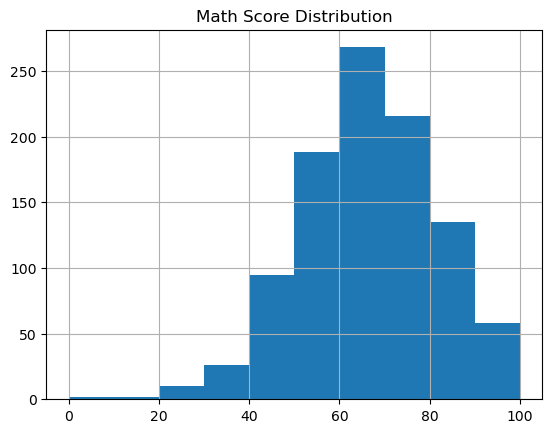

In [5]:
import matplotlib.pyplot as plt

data['math score'].hist()
plt.title("Math Score Distribution")
plt.show()

In [6]:
X = data[['reading score', 'writing score']]
y = data['math score']

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
predictions = model.predict(X_test)

print(predictions[:5])

[91.63149762 64.75883839 77.3941019  66.59256032 63.04091132]


In [9]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)
print("Error:", error)

Error: 6.978218057241764


In [10]:
data['Predicted_Math'] = model.predict(X)

data['Result'] = data['Predicted_Math'].apply(
    lambda x: "Pass" if x >= 40 else "Fail"
)

data[['Predicted_Math', 'Result']].head()

,Predicted_Math,Result
0,69.294046,Pass
1,83.776231,Pass
2,88.071049,Pass
3,52.737749,Pass
4,73.223879,Pass


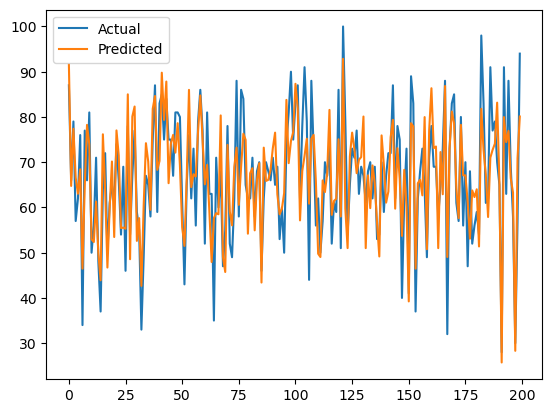

In [11]:
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.show()